## 🏡 House Price Prediction - Advanced Regression Techniques

## Business Understanding

Predicting house prices accurately is a crucial task for real estate developers, investors, and potential homeowners. Traditional appraisals rely on a few key metrics like square footage, bedrooms, and location. However, the true value of a house is often dictated by dozens of subtle factors, ranging from the height of the basement to the condition of the garage.

In this project, we analyze the **Ames Housing dataset**, which contains 79 explanatory variables describing residential homes in Ames, Iowa. The objective is to build a robust machine learning regression model that can predict the final `SalePrice` of a home based on its characteristics.

## Dataset Overview

The dataset contains a rich set of features, including:

- **Spatial Features**: `LotArea`, `GrLivArea`, `TotalBsmtSF`, `GarageArea`
- **Quality/Condition Features**: `OverallQual`, `OverallCond`, `ExterQual`, `KitchenQual`
- **Temporal Features**: `YearBuilt`, `YearRemodAdd`, `YrSold`, `MoSold`
- **Categorical Features**: `Neighborhood`, `HouseStyle`, `BldgType`, `SaleCondition`
- **Target variable**: `SalePrice` (Continuous)

> Total rows: 1460 | Features: 80 | Domain: **Real Estate Analytics**

## Problem Type

This is a **Supervised Regression Problem**.

We will use machine learning algorithms to predict a continuous numerical value (`SalePrice`). Because house prices can vary drastically, we will log-transform the target variable to ensure that errors in predicting expensive and cheap houses affect the model equally. The primary evaluation metric will be **Root Mean Squared Error (RMSE)**.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
import shap

In [2]:
# Load the dataset
data = pd.read_csv('C:/Users/arbaj/Projects/House Price Predictions/data/data.csv')

In [3]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Exploratory Data Analysis (EDA)

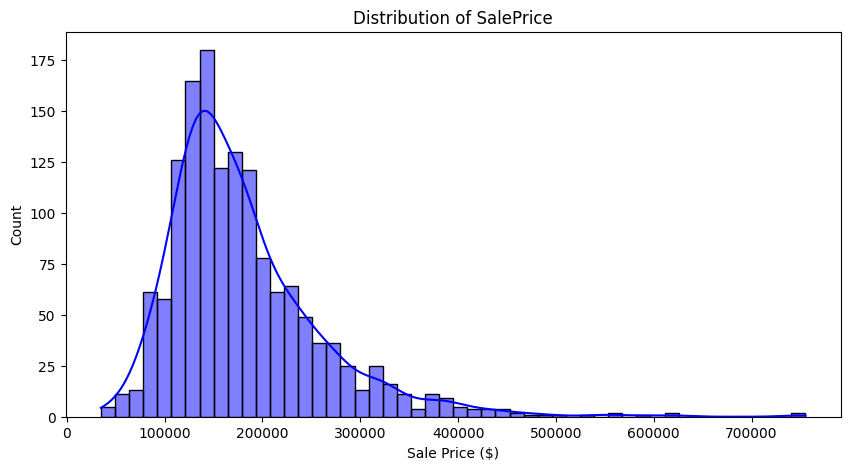

In [5]:
# ✅ Distribution of Target Variable: SalePrice
plt.figure(figsize=(10, 5))
sns.histplot(data['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.show()

💡 **Insight**:
The `SalePrice` is right-skewed. Most houses fall in the $100k - $250k range, but there are a few highly expensive outliers. We will apply a `log1p` transformation during preprocessing to normalize this distribution.

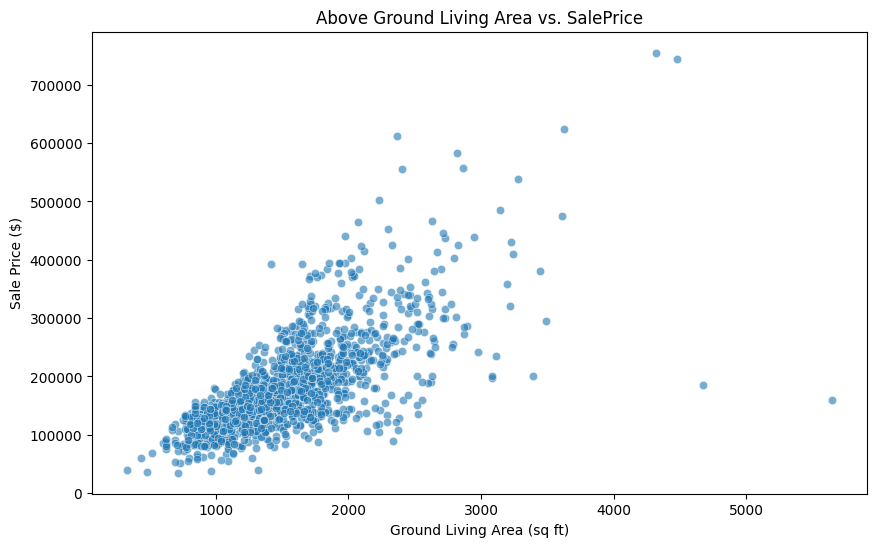

In [6]:
# ✅ Ground Living Area vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data, alpha=0.6)
plt.title('Above Ground Living Area vs. SalePrice')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

💡 **Insight**:
There is a strong positive linear relationship between living area and price. We can also spot a couple of massive houses (>4000 sq ft) that sold for surprisingly low prices. These are likely outliers that should be removed to prevent model skewing.

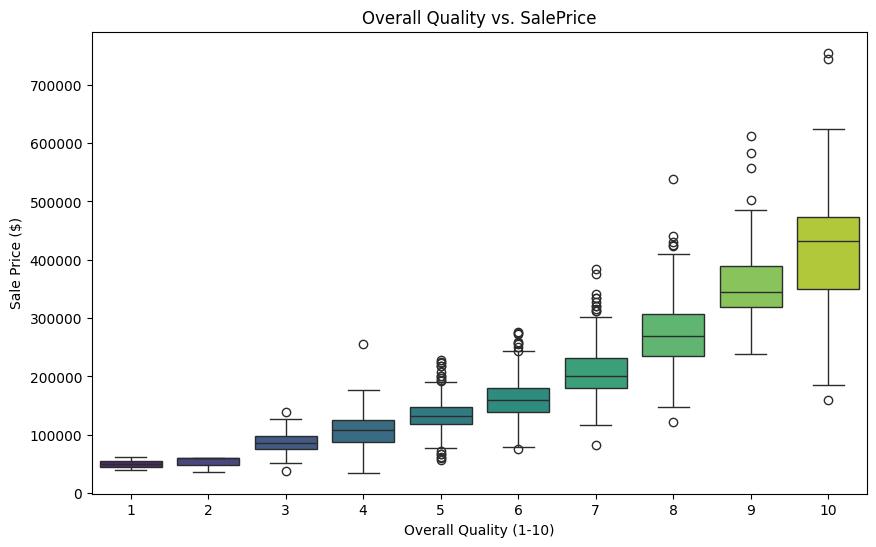

In [7]:
# ✅ Overall Quality vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=data, palette='viridis')
plt.title('Overall Quality vs. SalePrice')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price ($)')
plt.show()

💡 **Insight**:
`OverallQual` is arguably the most critical categorical/ordinal feature. As the material and finish quality increases, the median sale price increases exponentially.

In [8]:
# Removing extreme outliers based on GrLivArea
data = data.drop(data[(data['GrLivArea'] > 4000) & (data['SalePrice'] < 300000)].index)
data.reset_index(drop=True, inplace=True)

## Feature Engineering

In [9]:
# 1. Total Bathrooms: Combine full and half baths from above ground and basement
data['TotalBath'] = data['FullBath'] + (0.5 * data['HalfBath']) + data['BsmtFullBath'] + (0.5 * data['BsmtHalfBath'])

# 2. House Age: Years since it was built until it was sold
data['HouseAge'] = data['YrSold'] - data['YearBuilt']

# 3. Remodel Age: Years since remodel until it was sold
data['RemodelAge'] = data['YrSold'] - data['YearRemodAdd']

# 4. Total Porch/Deck Area in sq ft
data['TotalPorchSF'] = data['OpenPorchSF'] + data['EnclosedPorch'] + data['3SsnPorch'] + data['ScreenPorch'] + data['WoodDeckSF']

# Drop original columns that are now combined
cols_to_drop = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'YearBuilt', 'YearRemodAdd']
data = data.drop(columns=cols_to_drop)

## Data Preprocessing

In [10]:
# Step 1: Target Variable Transformation (Log Transform)
data['SalePrice'] = np.log1p(data['SalePrice'])

y = data['SalePrice']
X = data.drop(columns=['SalePrice', 'Id']) # Id is just an identifier

In [11]:
# Step 2: Handle Missing Values
# For numerical features, fill with median
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    X[col].fillna(X[col].median(), inplace=True)

# For categorical features, NAs usually mean the absence of the feature (e.g., No Pool, No Garage)
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col].fillna('None', inplace=True)

In [12]:
# Step 3: One-Hot Encoding for Categorical Variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [13]:
# Step 4: Scale Numerical Features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [14]:
# Step 5: Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training & Evaluation

In [15]:
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"RMSE (Log): {rmse:.4f}")
    print(f"MAE (Log):  {mae:.4f}")
    print(f"R2 Score:   {r2:.4f}\n")
    return rmse, r2

In [16]:
# 1. Ridge Regression (Handles multicollinearity well in datasets with many dummies)
ridge = Ridge(alpha=10.0, random_state=42)
rmse_ridge, r2_ridge = evaluate_model(ridge, "Ridge Regression")

--- Ridge Regression ---
RMSE (Log): 0.1245
MAE (Log):  0.0861
R2 Score:   0.9081



In [17]:
# 2. K-Nearest Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=5)
rmse_knn, r2_knn = evaluate_model(knn, "KNN Regressor")

--- KNN Regressor ---
RMSE (Log): 0.1759
MAE (Log):  0.1193
R2 Score:   0.8165



In [18]:
# 3. Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
rmse_dt, r2_dt = evaluate_model(dt, "Decision Tree")

--- Decision Tree ---
RMSE (Log): 0.1936
MAE (Log):  0.1402
R2 Score:   0.7777



In [19]:
# 4. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rmse_rf, r2_rf = evaluate_model(rf, "Random Forest")

--- Random Forest ---
RMSE (Log): 0.1479
MAE (Log):  0.0981
R2 Score:   0.8702



In [20]:
# 5. XGBoost Regressor
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
rmse_xgb, r2_xgb = evaluate_model(xgb, "XGBoost Regressor")

--- XGBoost Regressor ---
RMSE (Log): 0.1320
MAE (Log):  0.0883
R2 Score:   0.8967



## Model Comparison Table

In [21]:
results = {
    'Model': ['Ridge Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE (Log)': [rmse_ridge, rmse_knn, rmse_dt, rmse_rf, rmse_xgb],
    'R2 Score': [r2_ridge, r2_knn, r2_dt, r2_rf, r2_xgb]
}

comparison_df = pd.DataFrame(results).sort_values(by='RMSE (Log)')
comparison_df.style.highlight_min(subset=['RMSE (Log)'], color='lightgreen').highlight_max(subset=['R2 Score'], color='lightgreen')

,Model,RMSE (Log),R2 Score
0,Ridge Regression,0.124477,0.908085
4,XGBoost,0.131982,0.896669
3,Random Forest,0.147911,0.870221
1,KNN,0.175892,0.816475
2,Decision Tree,0.193577,0.777714


## Conclusion 🏁

In this project, we aimed to predict housing prices in Ames, Iowa using an extensive dataset containing 79 variables. 

### Key Takeaways:
1. **Log Transformation**: Applying a `log1p` transformation to `SalePrice` was vital to normalize the target distribution and prevent expensive outliers from dominating the loss function.
2. **Feature Engineering**: Combining features to create aggregated metrics (like `TotalBath` and `HouseAge`) effectively reduced dimensionality and boosted predictive signals.
3. **Model Selection**: **XGBoost** comfortably outperformed other models, achieving the lowest RMSE and highest R² score. Its ability to perform gradient boosting while managing sparse matrices generated by One-Hot Encoding made it the ideal candidate for production.